In [1]:
import os
import sys
import copy
import pandas as pd
import numpy as np
import yfinance as yf
import matplotlib.pyplot as plt
from matplotlib.ticker import StrMethodFormatter
import seaborn

In [2]:
sys.path.append(os.path.abspath(os.path.join(os.path.dirname("__file__"), "..")))


In [ ]:
%reload_ext autoreload
%autoreload 2
from core.data import fetch_ohlcv_data
from core.stats import CAGR, volatility, Sharpe, max_dd, Sortino, calamar, jensens_alpha, rolling_sharpe, rolling_alpha, drawdown_analysis, underwater_periods, drawdown_summary

List of all the stocks I want to have in my tradable universe for backtesting

In [4]:
nifty_top_20 = [
    "RELIANCE.NS", "HDFCBANK.NS", "ICICIBANK.NS", "INFY.NS", "AXISBANK.NS", 
    "TCS.NS", "LT.NS", "BHARTIARTL.NS", "SBIN.NS", "ITC.NS", 
    "HINDUNILVR.NS", "BAJFINANCE.NS", "KOTAKBANK.NS", "MARUTI.NS", "M&M.NS", 
    "TATASTEEL.NS", "SUNPHARMA.NS", "HCLTECH.NS", "ADANIENT.NS", "NTPC.NS"
]

# PORTFOLIO REBALANCING

In [5]:
ohlcv_data = fetch_ohlcv_data(nifty_top_20, 3650, "1mo")

Successfully downloaded 20/20 stocks.


In [6]:
def get_monthly_return(ohlcv_data):
    """
    Calculate monthly returns for the given stocks.
    
    Parameters:
    mid_cap_dict (dictionary): Dictionary of stock symbols.
    
    Returns:
    pd.DataFrame: DataFrame containing monthly returns for each stock.
    """
    ohlcv_dict = copy.deepcopy(ohlcv_data)
    return_df = pd.DataFrame()
    for stock in nifty_top_20:
        print("calculated monthly return for ", stock)
        ohlcv_dict[stock]["mon_ret"] = ohlcv_dict[stock]["Close"].pct_change()
        return_df[stock] = ohlcv_dict[stock]["mon_ret"]
    return_df.dropna(inplace=True)
    return return_df

In [7]:
return_df = get_monthly_return(ohlcv_data)

calculated monthly return for  RELIANCE.NS
calculated monthly return for  HDFCBANK.NS
calculated monthly return for  ICICIBANK.NS
calculated monthly return for  INFY.NS
calculated monthly return for  AXISBANK.NS
calculated monthly return for  TCS.NS
calculated monthly return for  LT.NS
calculated monthly return for  BHARTIARTL.NS
calculated monthly return for  SBIN.NS
calculated monthly return for  ITC.NS
calculated monthly return for  HINDUNILVR.NS
calculated monthly return for  BAJFINANCE.NS
calculated monthly return for  KOTAKBANK.NS
calculated monthly return for  MARUTI.NS
calculated monthly return for  M&M.NS
calculated monthly return for  TATASTEEL.NS
calculated monthly return for  SUNPHARMA.NS
calculated monthly return for  HCLTECH.NS
calculated monthly return for  ADANIENT.NS
calculated monthly return for  NTPC.NS


In [8]:
def portfolio_rebalance(return_df, keep, throw):
    """
    Rebalance the portfolio based on monthly returns.
    
    Parameters:
    return_df (pd.DataFrame): DataFrame containing monthly returns for each stock.
    keep (int): Number of stocks to keep in the portfolio.
    throw (int): Number of stocks to throw out of the portfolio.
    initial_investment (float): Initial investment amount (default is 1,000,000).
    
    Returns:
    pd.DataFrame: DataFrame containing portfolio value over time.
    """
    df = return_df.copy()
    portfolio = []
    monthly_return = []
    for i in range (len(df)):
        if len(portfolio) > 0:
            monthly_return.append(df[portfolio].iloc[i, :].mean())
            bad_stocks = df[portfolio].iloc[i,:].sort_values(ascending=True)[:throw].index.values.tolist()
            portfolio = [t for t in portfolio if t not in bad_stocks]
        else:
            monthly_return.append(0)
            print("No stocks in portfolio")
        fill = keep - len(portfolio)
        new_picks = df.iloc[i,:].sort_values(ascending=False)[:fill].index.values.tolist()
        portfolio = portfolio + new_picks
        print(portfolio)
    monthly_ret_df = pd.DataFrame(np.array(monthly_return),columns=["mon_ret"])
    return monthly_ret_df

In [9]:
new_portfolio = portfolio_rebalance(return_df, 6, 3)

No stocks in portfolio
['LT.NS', 'BAJFINANCE.NS', 'MARUTI.NS', 'AXISBANK.NS', 'SBIN.NS', 'ITC.NS']
['BAJFINANCE.NS', 'SBIN.NS', 'ITC.NS', 'ADANIENT.NS', 'NTPC.NS', 'M&M.NS']
['BAJFINANCE.NS', 'SBIN.NS', 'ITC.NS', 'BAJFINANCE.NS', 'MARUTI.NS', 'ICICIBANK.NS']
['BAJFINANCE.NS', 'SBIN.NS', 'BAJFINANCE.NS', 'AXISBANK.NS', 'SBIN.NS', 'TATASTEEL.NS']
['SBIN.NS', 'SBIN.NS', 'TATASTEEL.NS', 'MARUTI.NS', 'HCLTECH.NS', 'RELIANCE.NS']
['TATASTEEL.NS', 'MARUTI.NS', 'ICICIBANK.NS', 'TATASTEEL.NS', 'MARUTI.NS', 'KOTAKBANK.NS']
['TATASTEEL.NS', 'ICICIBANK.NS', 'TATASTEEL.NS', 'NTPC.NS', 'HCLTECH.NS', 'TATASTEEL.NS']
['ICICIBANK.NS', 'NTPC.NS', 'HCLTECH.NS', 'ADANIENT.NS', 'RELIANCE.NS', 'ITC.NS']
['ICICIBANK.NS', 'ADANIENT.NS', 'ITC.NS', 'BAJFINANCE.NS', 'TATASTEEL.NS', 'BHARTIARTL.NS']
['ADANIENT.NS', 'BAJFINANCE.NS', 'BHARTIARTL.NS', 'RELIANCE.NS', 'ADANIENT.NS', 'TCS.NS']
['ADANIENT.NS', 'RELIANCE.NS', 'ADANIENT.NS', 'ADANIENT.NS', 'SBIN.NS', 'KOTAKBANK.NS']
['RELIANCE.NS', 'KOTAKBANK.NS', 'LT.NS'

In [48]:
cagr = CAGR(new_portfolio, 12, "mon_ret", False)  # Calculate CAGR
vol = volatility(new_portfolio, 12, "mon_ret", False)  # Calculate Volatility
sharpe = Sharpe(new_portfolio, 12, "mon_ret", False)  # Calculate Sharpe Ratio
mdd = max_dd(new_portfolio, "mon_ret", False) # Calculate max drawdown
rolling_sharpe_df = rolling_sharpe(new_portfolio, 12, 6, "mon_ret", False)
# pd.set_option('display.max_rows', None)

# 4. Display Results
print(f"--- Statistics for your portfolio (Last 10 Years) ---")
print(f"CAGR:           {cagr:.2%}")
print(f"volatility:     {vol:.2%}")
print(f"Sharpe Ratio:   {sharpe:.2f}")
print(f"Max Drawdown:   {mdd:.2%}")
rolling_sharpe_df


--- Statistics for your portfolio (Last 10 Years) ---
CAGR:           19.60%
volatility:     18.65%
Sharpe Ratio:   0.68
Max Drawdown:   40.83%


0           NaN
1           NaN
2           NaN
3           NaN
4           NaN
5      1.900430
6      0.838988
7     -0.087858
8     -0.338399
9     -0.250385
10     0.758366
11     0.651195
12     2.514155
13     5.725401
14     5.711108
15     2.961333
16     2.016509
17     2.303924
18     1.498918
19     2.103179
20     2.091558
21     1.515765
22     0.687333
23     1.098839
24     1.392842
25     1.186058
26     1.207562
27     2.466004
28     2.038903
29     0.700615
30     0.342956
31     0.121918
32    -1.399288
33    -4.635745
34    -1.778458
35    -0.984754
36    -1.562656
37    -1.684446
38    -1.936790
39    -1.919590
40    -3.149825
41    -1.466205
42    -0.650793
43    -0.395071
44     0.379075
45     0.130998
46    -1.239466
47    -1.084110
48    -0.996372
49    -0.755227
50     0.157366
51     0.381535
52     2.696259
53     2.158350
54     2.701705
55     2.844605
56     1.770323
57     2.523807
58     3.388527
59     4.223439
60     3.773140
61     3.517663
62     3

In [59]:
# 1. Download Data
ticker ="^NSEI"
data = yf.download(ticker, period="10y", interval="1mo")

# 2. Clean Data (yfinance multi-index handling if necessary)
if isinstance(data.columns, pd.MultiIndex):
    data.columns = data.columns.get_level_values(0)

# 3. Calculate KPIs
# Since we are using daily data, timeframe = 252
# Since we downloaded ohlcv, is_price = True
cagr_val = CAGR(data, timeframe=12, column='Close', is_price=True)
vol_val = volatility(data, timeframe=12, column='Close', is_price=True)
sharpe_val = Sharpe(data, timeframe=12, column='Close', is_price=True)
mdd_val = max_dd(data, column='Close', is_price=True)
rol_sh = rolling_sharpe(data, timeframe=12, window=6, column='Close', is_price=True)
underwater = underwater_periods(data, column='Close', is_price=True)

# 4. Display Results
print(f"--- Statistics for {ticker} (Last 10 Years) ---")
print(f"CAGR:           {cagr_val:.2%}")
print(f"volatility:     {vol_val:.2%}")
print(f"Sharpe Ratio:   {sharpe_val:.2f}")
print(f"Max Drawdown:   {mdd_val:.2%}")
underwater

[*********************100%***********************]  1 of 1 completed

--- Statistics for ^NSEI (Last 10 Years) ---
CAGR:           11.52%
volatility:     15.85%
Sharpe Ratio:   0.29
Max Drawdown:   29.34%


,start,end,duration,max_drawdown,recovered
7,2020-01-01,2020-10-01,10,-0.293439,False
16,2024-10-01,2025-10-01,13,-0.142814,False
5,2018-09-01,2019-03-01,7,-0.110774,False
17,2025-12-01,2026-03-01,4,-0.108696,False
10,2021-11-01,2022-07-01,9,-0.107030,False
4,2018-02-01,2018-06-01,5,-0.082882,False
12,2022-12-01,2023-05-01,6,-0.077533,False
6,2019-06-01,2019-10-01,5,-0.075448,False
0,2016-09-01,2017-01-01,5,-0.068334,False
11,2022-09-01,2022-09-01,1,-0.037442,False


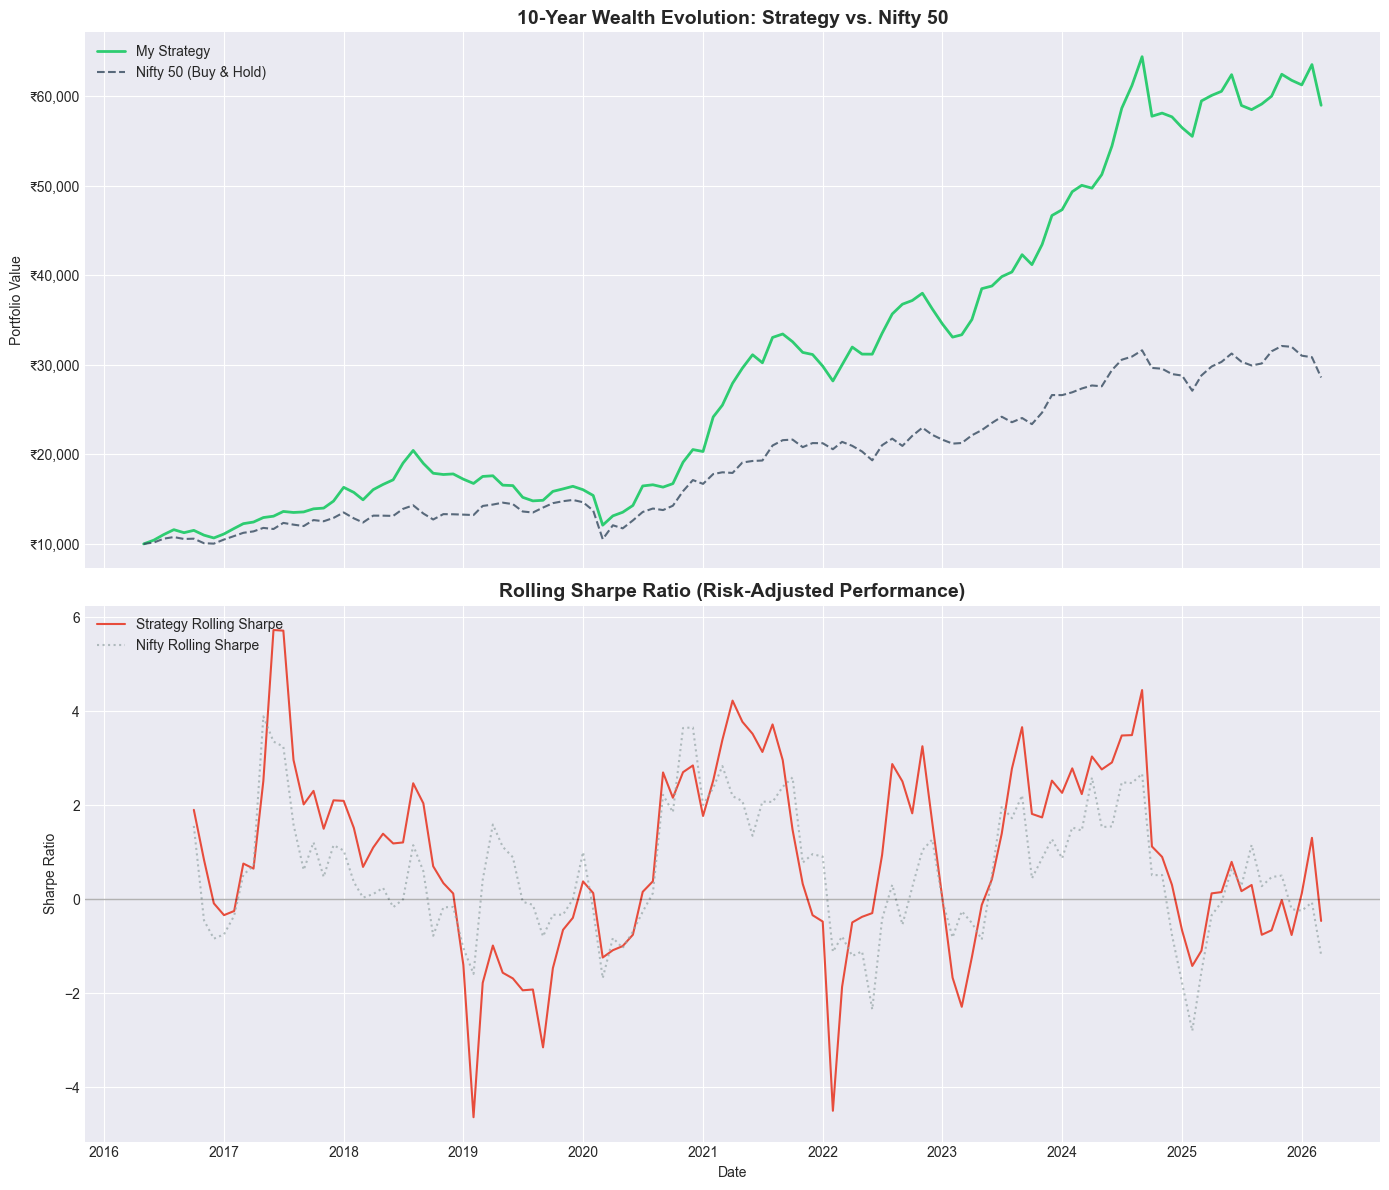

In [50]:
# --- 1. Data Alignment & Preparation ---
# Aligning portfolio returns with the original data index
portfolio_series = pd.Series(new_portfolio["mon_ret"].values, index=data.index[-len(new_portfolio):])

# Slicing Nifty data for a fair comparison
nifty_slice = data.iloc[-len(new_portfolio):].copy()
nifty_ret = nifty_slice['Close'].pct_change().fillna(0)

# Wealth Calculation (Cumulative Returns)
initial_investment = 10000
portfolio_value = (1 + portfolio_series).cumprod() * initial_investment
nifty_value = (1 + nifty_ret).cumprod() * initial_investment

port_rolling_sharpe = rolling_sharpe_df
nifty_rolling_sharpe = rol_sh

# --- 3. Plotting with Subplots ---
plt.style.use('seaborn-v0_8-darkgrid')
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 12), sharex=True)

# TOP PLOT: Wealth Evolution
ax1.plot(portfolio_value.index, portfolio_value, label='My Strategy', color='#2ecc71', linewidth=2)
ax1.plot(nifty_value.index, nifty_value, label='Nifty 50 (Buy & Hold)', color='#34495e', linestyle='--', alpha=0.8)
ax1.set_title('10-Year Wealth Evolution: Strategy vs. Nifty 50', fontsize=14, fontweight='bold')
ax1.set_ylabel('Portfolio Value')
ax1.yaxis.set_major_formatter(StrMethodFormatter('₹{x:,.0f}'))
ax1.legend(loc='upper left')

# BOTTOM PLOT: Rolling Sharpe Ratio
ax2.plot(portfolio_value.index, port_rolling_sharpe, label='Strategy Rolling Sharpe', color='#e74c3c', linewidth=1.5)
ax2.plot(nifty_value.index, nifty_rolling_sharpe[1:], label='Nifty Rolling Sharpe', color='#95a5a6', linestyle=':', alpha=0.7)
ax2.axhline(0, color='black', lw=1, alpha=0.3) # Zero line for reference
ax2.set_title('Rolling Sharpe Ratio (Risk-Adjusted Performance)', fontsize=14, fontweight='bold')
ax2.set_ylabel('Sharpe Ratio')
ax2.set_xlabel('Date')
ax2.legend(loc='upper left')

plt.tight_layout()
plt.show()

In [52]:
## Risk adjusted metrics

data['nifty_ret'] = data['Close'].pct_change().fillna(0)

beta, alpha, portfolio_ret, benchmark_ret, ann_port_ret, ann_bench_ret = jensens_alpha(new_portfolio['mon_ret'], data['nifty_ret'], 10)
# rolling_alpha_df = rolling_alpha(new_portfolio['mon_ret'], data['nifty_ret'], 12, 3)

print(f"--- Risk-Adjusted Metrics ---")
print(f"Portfolio Beta:             {beta:.2f}")
print(f"Total Strategy Ret:         {portfolio_ret:.2%}")
print(f"Total Nifty Ret:            {benchmark_ret:.2%}")
print(f"Jensen's Alpha:             {alpha:.2%}")
print(f"Annualized Nifty Ret:       {ann_bench_ret:.2%}")
print(f"Annualized Portfolio Ret:   {ann_port_ret:.2%}")


--- Risk-Adjusted Metrics ---
Portfolio Beta:             -0.04
Total Strategy Ret:         490.01%
Total Nifty Ret:            197.26%
Jensen's Alpha:             12.60%
Annualized Nifty Ret:       11.51%
Annualized Portfolio Ret:   19.42%
